In [1]:
import pandas as pd
import numpy as np

# Carga
df = pd.read_csv("../../data/processed/weather_processed.csv")

X = df.drop(columns=["Rain"])
y = df["Rain"]

print(X.columns.tolist())

['SNOW', 'SNWD', 'TMAX', 'TMIN', 'ADPT', 'ASLP', 'ASTP', 'AWBT', 'AWND', 'RHAV', 'RHMN', 'RHMX', 'WDF2', 'WDF5', 'WSF2', 'WSF5', 'year', 'month', 'day', 'dayofweek', 'month_sin', 'month_cos']


In [2]:
print(X.head())

   SNOW   SNWD  TMAX  TMIN   ADPT     ASLP    ASTP  AWBT  AWND  RHAV  ...  \
0  13.0  250.0 -10.0 -55.0  -56.0   9942.0  9705.0 -39.0  28.0  83.0  ...   
1   0.0  250.0   6.0 -55.0  -61.0  10037.0  9793.0 -39.0  24.0  77.0  ...   
2   3.0  200.0  33.0 -43.0  -17.0  10037.0  9804.0   0.0  18.0  85.0  ...   
3   0.0  180.0  28.0 -21.0  -33.0  10047.0  9810.0 -17.0  20.0  79.0  ...   
4  18.0  200.0 -16.0 -93.0 -100.0  10030.0  9783.0 -72.0  56.0  75.0  ...   

    WDF2   WDF5   WSF2   WSF5  year  month  day  dayofweek  month_sin  \
0  300.0  280.0   54.0   81.0  2020      1    1          2        0.5   
1  250.0  250.0   67.0   98.0  2020      1    2          3        0.5   
2  240.0  240.0   63.0   85.0  2020      1    3          4        0.5   
3  330.0  320.0   45.0   58.0  2020      1    4          5        0.5   
4  330.0  340.0  103.0  143.0  2020      1    5          6        0.5   

   month_cos  
0   0.866025  
1   0.866025  
2   0.866025  
3   0.866025  
4   0.866025  

[5 rows

In [3]:
X = X.drop(columns=["day"])

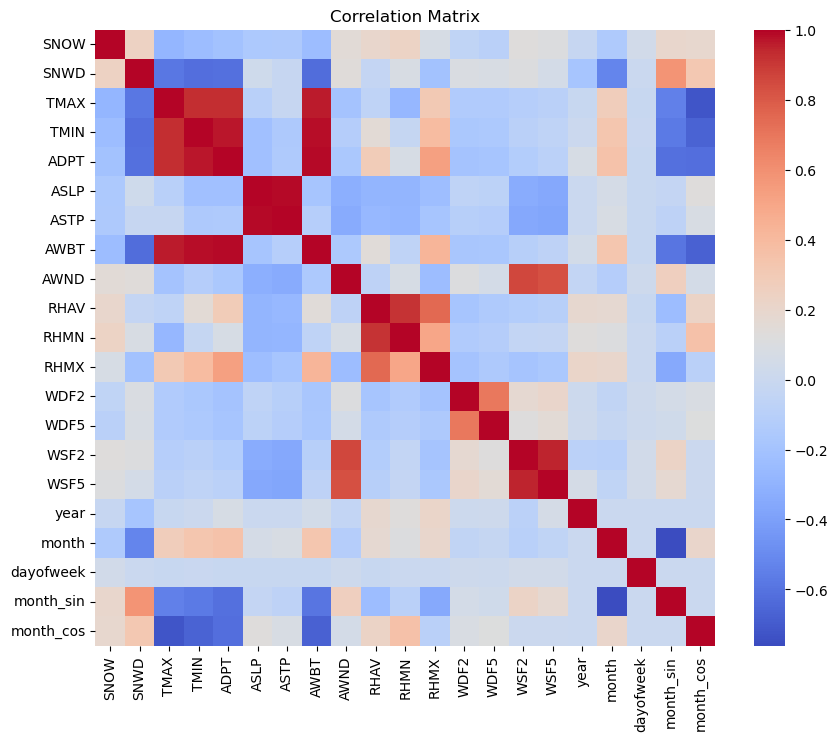

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

SNOW         0.152418
RHAV         0.132120
RHMN         0.086037
RHMX         0.066618
ASLP         0.056246
TMAX         0.049143
WSF5         0.048173
ASTP         0.045626
AWND         0.045149
TMIN         0.042070
WSF2         0.040185
ADPT         0.037160
WDF5         0.034102
WDF2         0.033047
AWBT         0.030176
month        0.020875
dayofweek    0.020863
month_sin    0.017592
month_cos    0.016391
year         0.013510
SNWD         0.012498
dtype: float64


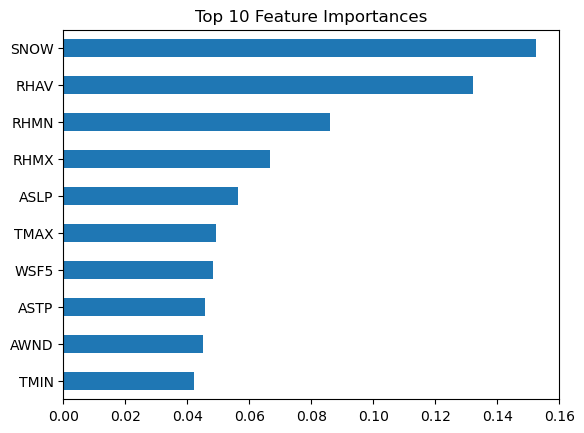

In [6]:
importances.head(10).plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [7]:
df.to_csv("../../data/processed/weather_processed_WITHSNOW.csv", index=False)

In [8]:
X = X.drop(columns=["SNOW", "SNWD"])
X = X.drop(columns=["year"])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [16]:
X.isna().sum().sort_values(ascending=False).head(10)

ASTP    372
ASLP    372
ADPT    367
AWBT    367
RHAV    365
RHMN    365
RHMX    365
WDF5     10
WSF5     10
AWND      8
dtype: int64

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

pipeline_base = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

pipeline_kbest = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(score_func=f_classif, k=10)),
    ("model", LogisticRegression(max_iter=1000))
])

In [19]:
from sklearn.decomposition import PCA

pipeline_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)), # Retener el 95% de la varianza
    ("model", LogisticRegression(max_iter=1000))
])

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [23]:
models = {
    "Base": pipeline_base,
    "KBest": pipeline_kbest,
    "PCA": pipeline_pca
}

from sklearn.model_selection import cross_val_score

for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    roc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    
    print(f"{name}:")
    print(f"  Accuracy: {acc.mean():.4f}")
    print(f"  ROC-AUC:  {roc.mean():.4f}")
    print()

Base:
  Accuracy: 0.7889
  ROC-AUC:  0.8717

KBest:
  Accuracy: 0.7747
  ROC-AUC:  0.8612

PCA:
  Accuracy: 0.7712
  ROC-AUC:  0.8587



In [24]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf_base = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_rf_kbest = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(score_func=f_classif, k=10)),
    ("model", RandomForestClassifier(random_state=42))
])

pipeline_rf_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", RandomForestClassifier(random_state=42))
])

In [25]:
from sklearn.svm import SVC

pipeline_svm_base = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

pipeline_svm_kbest = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(score_func=f_classif, k=10)),
    ("model", SVC(probability=True, random_state=42))
])

pipeline_svm_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", SVC(probability=True, random_state=42))
])

In [36]:
from xgboost import XGBClassifier

pipeline_xgb_base = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

pipeline_xgb_kbest = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("kbest", SelectKBest(score_func=f_classif, k=10)),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

pipeline_xgb_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])

In [37]:
models = {
    # Random Forest
    "RF_Base": pipeline_rf_base,
    "RF_KBest": pipeline_rf_kbest,
    "RF_PCA": pipeline_rf_pca,

    # SVM
    "SVM_Base": pipeline_svm_base,
    "SVM_KBest": pipeline_svm_kbest,
    "SVM_PCA": pipeline_svm_pca,

    # XGBoost
    "XGB_Base": pipeline_xgb_base,
    "XGB_KBest": pipeline_xgb_kbest,
    "XGB_PCA": pipeline_xgb_pca,
}

In [38]:
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    roc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    
    print(f"{name}:")
    print(f"  Accuracy: {acc.mean():.4f}")
    print(f"  ROC-AUC:  {roc.mean():.4f}")
    print()

RF_Base:
  Accuracy: 0.7884
  ROC-AUC:  0.8620

RF_KBest:
  Accuracy: 0.7758
  ROC-AUC:  0.8494

RF_PCA:
  Accuracy: 0.7536
  ROC-AUC:  0.8385

SVM_Base:
  Accuracy: 0.7901
  ROC-AUC:  0.8683

SVM_KBest:
  Accuracy: 0.7849
  ROC-AUC:  0.8630

SVM_PCA:
  Accuracy: 0.7764
  ROC-AUC:  0.8546

XGB_Base:
  Accuracy: 0.7775
  ROC-AUC:  0.8569

XGB_KBest:
  Accuracy: 0.7684
  ROC-AUC:  0.8443

XGB_PCA:
  Accuracy: 0.7473
  ROC-AUC:  0.8303



In [40]:
df.to_csv("../../data/processed/weather_processed.csv", index=False)